# Adaptive Noise Gate
An adaptive noise gate where the thresholds track recent frame energies, allowing the system to adjust dynamically to changing noise environments.

## Creating a test signal

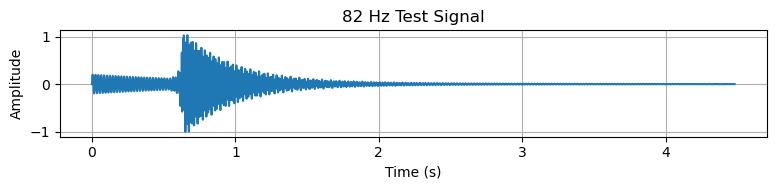

In [1]:
import numpy as np
from utils import (create_guitar_signal,  
                   create_sinewave, 
                   plot_gate_debug,
                   plot_signal,
                   load_floats_csv)
frame_len = 1024
freq = 82
fs = 8000
N1, N2 = 30,  5
hum_freq, hum_amp = 50, 0.2

s1, _ = create_guitar_signal(fs, freq, N1*frame_len, amplitude=1, decay_rate=3.0)
s2, _ = create_guitar_signal(fs, freq, N2*frame_len, amplitude=1, decay_rate=45.0)
s3, _ = create_sinewave(fs, hum_freq, (N1 + N2)*frame_len, hum_amp,1)

s2_rev = s2[::-1]
signal = np.concatenate([s2_rev, s1]) + s3
time = np.arange(len(signal)) / fs

plot_signal(signal=signal, time=time, title=f"{freq} Hz Test Signal", figsize=(8, 2))

## Adaptive Noise Gate
An adaptive noise gate that processes audio one frame at a time while maintaining a rolling history of the last 20 frames below the threshold. The noise floor is estimated from this history, and the open/close thresholds drift with recent frame energies, allowing the gate to adapt dynamically to varying background noise levels and environments.

In [2]:
import numpy as np
from collections import deque
CLOSED, OPEN = 0,1 
EPS = 1e-20
LEAK_FACTOR = 0.05
LEAK_CAP_DB   = 6

class FrameState:
    def __init__(self, Nbuf=20, floor_pct=20, delta_on=9.0, delta_off=4.0, hang_frames=8):
        self.Nbuf = Nbuf
        self.floor_pct = floor_pct
        self.delta_on_db = delta_on
        self.delta_off_db = delta_off
        self.hang_frames = hang_frames
        self.buf = deque(maxlen=Nbuf)
        self.gate = CLOSED
        self.hang = 0
        self.init = False
        self.prev_floor_db = EPS
        self.leak_open = True
        self.leak_factor = 0.1

def adaptive_noise_gate_step(frame, st):
    frame_energy = float(np.sum(frame**2))
    E_db = 10.0 * np.log10(max(frame_energy, EPS))

    if not st.init:
        st.init = True
        st.buf.clear()
        st.buf.append(E_db)
        st.gate = CLOSED
        st.hang = st.hang_frames
        st.prev_floor_db = E_db
        gate_switch_on = st.prev_floor_db + st.delta_on_db
        gate_switch_off = st.prev_floor_db + st.delta_off_db
        return E_db, E_db, gate_switch_on, gate_switch_off, st.gate

    
    gate_switch_on =  st.prev_floor_db + st.delta_on_db
    gate_switch_off = st.prev_floor_db + st.delta_off_db

    if st.gate == CLOSED:
        if E_db >= gate_switch_on:
            st.gate = OPEN
            st.hang = st.hang_frames
    else:
        if (E_db <= gate_switch_off) and (st.hang == 0):
            st.gate = CLOSED
        else:
            st.hang = max(st.hang - 1, 0)

    if st.gate == CLOSED:
        st.buf.append(E_db)
    elif st.leak_open:
        E_db_leak = (1.0 - st.leak_factor) * st.prev_floor_db + st.leak_factor * E_db
        st.buf.append(E_db_leak)

    floor_db = np.percentile(st.buf, st.floor_pct)
    st.prev_floor_db = floor_db

    return E_db, floor_db, gate_switch_on, gate_switch_off, st.gate

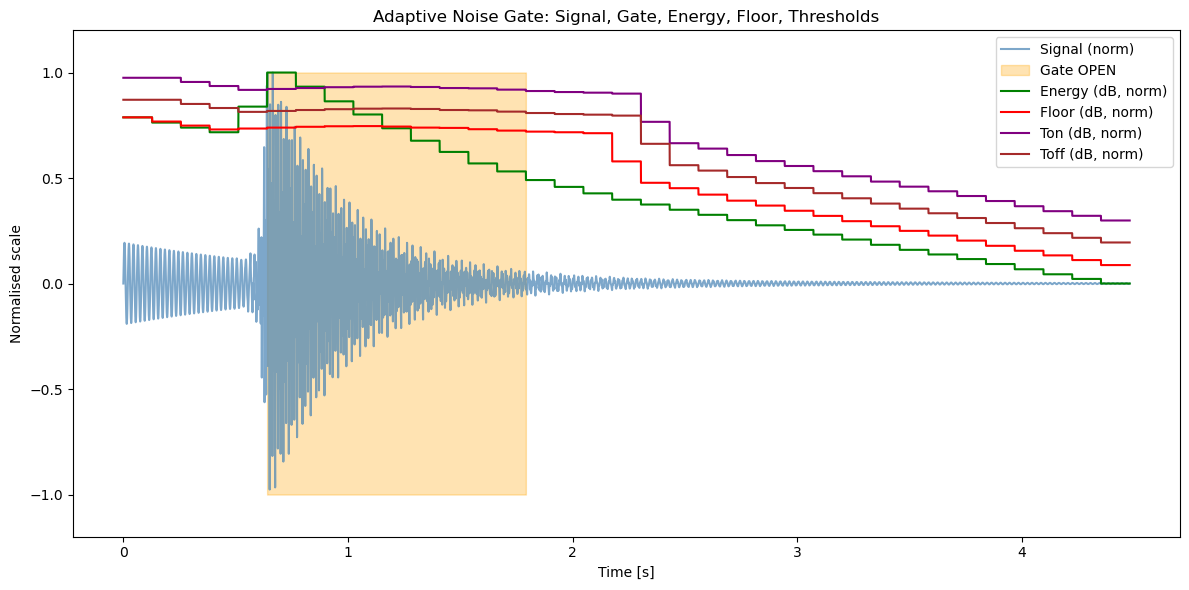

In [3]:
def run_adaptive_gate(signal, frame_len, fs, state):

    n_frames = len(signal) // frame_len
    signal = signal[: n_frames * frame_len]
    time = np.arange(len(signal)) / fs

    Ton_list, Toff_list, E_db_list, F_list, gate_list = [], [], [], [], []
    

    for i in range(n_frames):
        frame = signal[i*frame_len : (i+1)*frame_len]
        E_db, F, Ton, Toff, gate = adaptive_noise_gate_step(frame, state)

        Ton_list.append(np.full(frame_len, Ton))
        Toff_list.append(np.full(frame_len, Toff))
        E_db_list.append(np.full(frame_len, E_db))
        F_list.append(np.full(frame_len, F))
        gate_list.append(np.full(frame_len, gate))

    Ton_arr  = np.concatenate(Ton_list)
    Toff_arr = np.concatenate(Toff_list)
    E_db_arr = np.concatenate(E_db_list)
    F_arr    = np.concatenate(F_list)
    gate_arr = np.concatenate(gate_list)

    return time, signal, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr

st = FrameState()
t, x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr = \
    run_adaptive_gate(signal, frame_len=1024, fs=8000.0, state=st)

plot_gate_debug(time, signal, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr)

## Real Piezo Signal

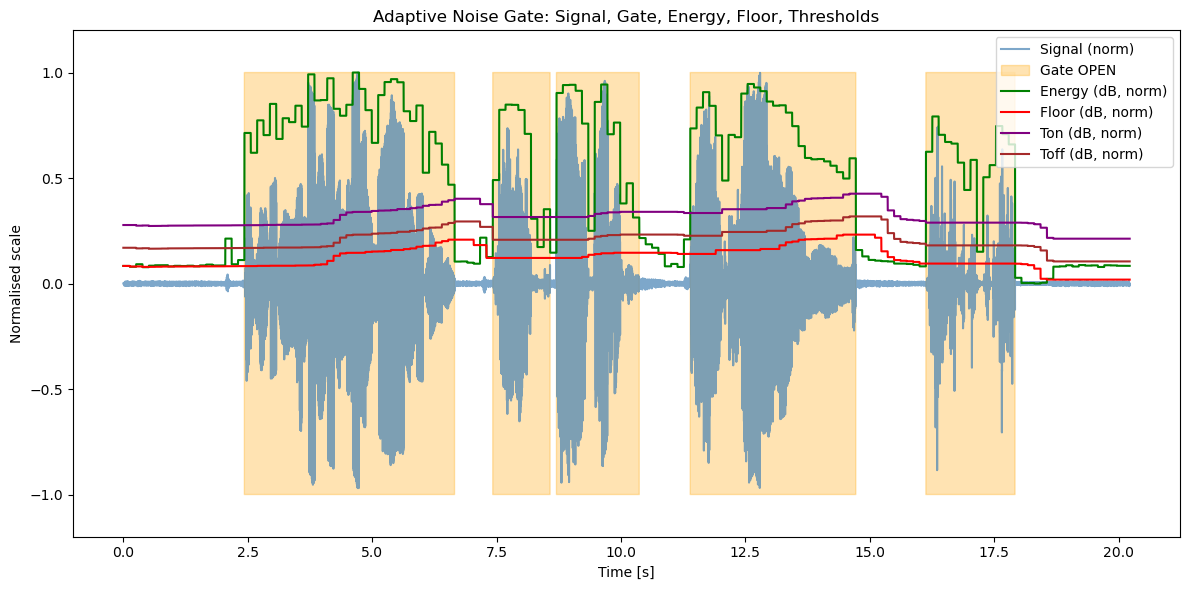

In [4]:
signal_E2 = load_floats_csv("data/E2_signal.csv")
signal_A2 = load_floats_csv("data/A2_signal.csv")
signal_B3 = load_floats_csv("data/B3_signal.csv")
signal_floor = load_floats_csv("data/noise_floor.csv")
signal_bumps = load_floats_csv("data/bumps_signal.csv")

signal = np.concatenate([signal_floor, 
                         signal_B3, 
                         signal_A2, 
                         signal_E2, 
                         signal_bumps, 
                         signal_floor])

st = FrameState()
t, x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr = \
    run_adaptive_gate(signal, frame_len=1024, fs=8000.0, state=st)

plot_gate_debug(t,x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr)



## Adaptive noise floor test
By introducing a slowly varying noise floor, we can observe how the adaptive gate adjusts its thresholds in real time. The gate follows the drifting floor while still opening cleanly for true note onsets.


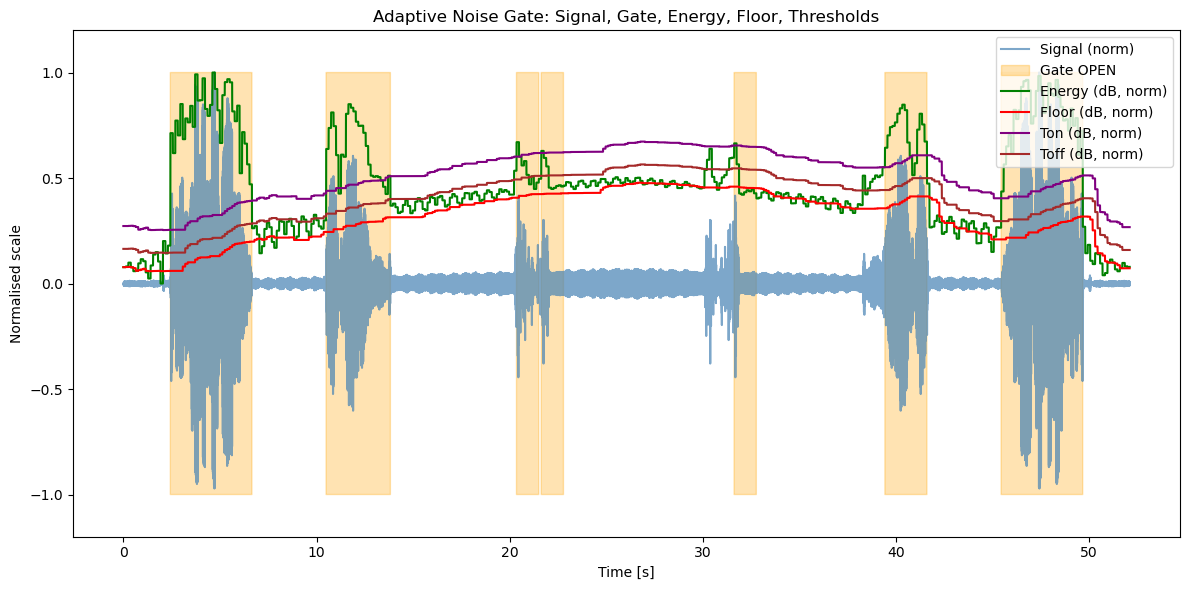

In [5]:

signal = np.concatenate([signal_floor, 
                         signal_B3, 
                         signal_floor, 
                         signal_floor,
                         signal_E2*0.6, 
                         signal_floor, 
                         signal_floor,
                         signal_floor,
                         signal_bumps*0.5,
                         signal_floor,
                         signal_floor])


hum, _ = create_sinewave(fs, 50, len(signal), 1.0, decay_rate=-0.01)
ramp = np.linspace(0, 0.05, len(signal))
hum = hum * ramp
signal = signal + hum
signal = np.concatenate([signal, signal[::-1]])
st = FrameState()
t, x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr = \
    run_adaptive_gate(signal, frame_len=1024, fs=8000.0, state=st)

plot_gate_debug(t,x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr)

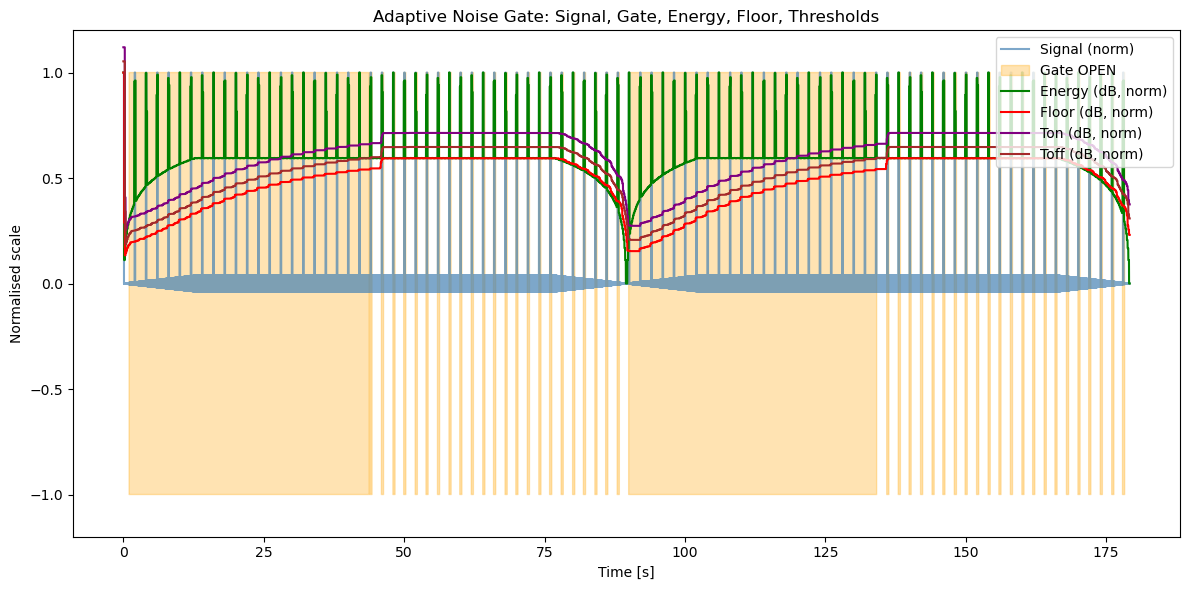

In [6]:

N_up     = 1024*100
N_steady = 1024*500
N_down   = 1024*100
A_peak   = 0.03       
N = N_up + N_steady + N_down
t = np.arange(N) / fs
signal, _ = create_sinewave(fs, 50, N, amplitude=1.0, decay_rate=0)
signal = np.asarray(signal, dtype=float)
env = np.concatenate([
    np.linspace(0.0, A_peak, N_up, endpoint=False),
    np.full(N_steady, A_peak),
    np.linspace(A_peak, 0.0, N_down, endpoint=True),
])
signal *= env
signal = np.concatenate([signal, signal])
t = np.arange(len(signal)) / fs
pulse_mask = (t % 2) < 0.1     
signal[pulse_mask] = 0.8           


st = FrameState(hang_frames=2)
t, x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr = \
    run_adaptive_gate(signal, frame_len=1024, fs=8000.0, state=st)
plot_gate_debug(t,x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr)